In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
spkws = dict(projection = ccrs.PlateCarree(), transform = ccrs.PlateCarree())

from siphon.catalog import TDSCatalog
#from xclim.core.calendar import convert_calendar, percentile_doy
import xclim.indicators as xci

# pysal.esda for spatial autocorrelation analysis
import esda 
import libpysal as lps

D:\anaconda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Function for calculating suitability for nematode transmission

In [2]:
# Load the csv file containing suitability at each temperature
suitability = pd.read_csv("data-processed/S.output.lowerCI.csv") 
suitability = suitability[["temp", "scaled_lowerCI"]]
suitability[suitability['scaled_lowerCI'] > 0]

,temp,scaled_lowerCI
164,16.4,0.000008
165,16.5,0.000671
166,16.6,0.001917
167,16.7,0.003531
168,16.8,0.005715
...,...,...
261,26.1,0.647509
262,26.2,0.540974
263,26.3,0.465053
264,26.4,0.317545


In [3]:
# Create an interpolation function such that the suitability of any temperature can be calculated (even if it is not in the csv file)

from scipy.interpolate import interp1d
suit_func = interp1d(suitability["temp"], suitability["scaled_lowerCI"], 
                     bounds_error=False, fill_value=0)
suit_func

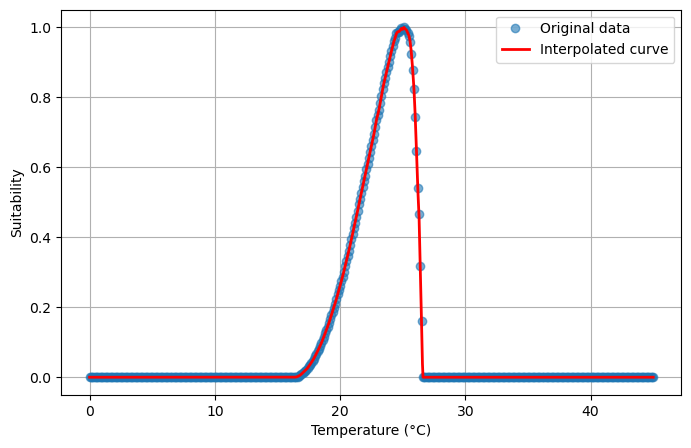

In [4]:
# Check the interpolation function
temps = np.linspace(suitability["temp"].min(), suitability["temp"].max(), 1000)

plt.figure(figsize = (8,5))
plt.plot(suitability["temp"], suitability["scaled_lowerCI"], 'o', label="Original data", alpha=0.6)
plt.plot(temps, suit_func(temps), '-', label = "Interpolated curve", color='red', linewidth=2)
plt.xlabel("Temperature (°C)")
plt.ylabel("Suitability")
plt.legend()
plt.grid(True)
plt.show()

Below are some functions to calculate thermal suitability and to test whether mean changes are significant. The first function, effective_sample_size, calculates the effective sample size to account for non-independence between serially correlated data points. The second function, get_suitability, calculates the number of days that S(T) > 0.001 for each grid cell in each year, as well as some summary statistics for significance testing.

In [5]:
# function for calculating effective sample size, copied section 3.4 from the guidebook
def effective_sample_size(data):
    ntime = len(data.time)
    # times not including the final timestep
    times = data.time.isel(time = slice(0, ntime - 1))
    # data not including the first timestep
    data_lag = data.isel(time = slice(1, ntime))
    # match up time values, otherwise the xr.corr function won't return the correct output
    data_lag = data_lag.assign_coords(time = times)
    
    # calculate correlation
    autocor = xr.corr(data.sel(time = times),
                      data_lag,
                      dim = 'time')
    
    neff = ntime * (1 - autocor) / (1 + autocor)
    
    return neff

In [6]:
def get_suitability(data, thres = 0.001):
    
    # Find suitability in each year
    S = xr.apply_ufunc(
        suit_func,
        # data.temperature,
        data.tas,
        dask="parallelized",
        output_dtypes=[float])
    
    # Get effective sample size for each period, for significance testing later on
    neff = effective_sample_size(S)

    # Count the number of days where S > thres in each year

    # S = S.where(~np.isnan(data.temperature))
    S = S.where(~np.isnan(data.tas))
    
    suit_days = S > thres
    days_per_year = suit_days.groupby("time.year").sum(dim = "time")

    # Keep land mask
    # mask = data.temperature.isel(time=0).isnull()
    mask = data.tas.isel(time=0).isnull()
    days_per_year = days_per_year.where(~mask)
    
    # Summary statistics (mean and stdev) - inputs for ttest_ind_from_stats
    suit_days_mean = days_per_year.mean('year') # Calculate the mean # of days where S across the whole period
    suit_days_std = days_per_year.std('year') #Standard deviation
    
    ds_out = xr.Dataset({'mean': suit_days_mean, 
                         'std': suit_days_std, 
                         'neff': neff})
    
    return ds_out

# 2. Climate data
Here we will use a publicly available downscaled gridded data from PCIC. PCIC used observations from NRCAN gridded data from 1950 - 2005 to perform BCCAQv2 downscaling.

In [2]:
# acquire downscaled data from PAVICS - same as section 4.4
url_pavics = "https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/datasets/"
url_downscaled = url_pavics + "simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/catalog.xml"
cat_sds = TDSCatalog(url_downscaled)

# open the downscaled gcm dataset and load the data
opendap_urls = [cat_sds.datasets[i].access_urls["OPENDAP"] for i in range(len(cat_sds.datasets))]
datasets_canesm_sds = list(filter(lambda x: 'CanESM' in x, opendap_urls))

datasets_canesm_sds

['https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r10i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r1i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r2i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r3i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r4i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ou

This time we will use CanESM5 ensemble member r1i1p2f1

## 2a. SSP2-4.5

In [9]:
ssp245_url = datasets_canesm_sds[11] #SSP2-4.5; ensemble member: r1i1p2f1
print(ssp245_url)
ssp245_all = xr.open_dataset(ssp245_url)[['tasmax','tasmin']]

https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp245_r1i1p2f1_gn_1950-2100.ncml


In [11]:
# select spatial domain (all of Canada)
# lat_bnds = [41, 90]
# lon_bnds = [-143, -52]

# select spatial domain (Down to central Manitoba)
#lat_bnds = [55, 90]
#lon_bnds = [-143, -59]


# select spatial domain
#ssp245 = ssp245_all.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))
ssp245 = ssp245_all

### 2a.i Saving the climate data

We need daily mean temperature. However, this dataset only contains the daily maximum and daily minimum temperatures. To get the daily mean temperature, we will take the average of the daily maximum and daily minimum. Since the dataset is too large, we will subset the dataset by year and compute the mean temperature.

In [32]:
start_year = 1980
end_year = 1980

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    # outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    outfile = f"tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1980...
Finished processing year 1980. Now saving file...
Saved tas_day_CanESM5_ssp245_r1i1p2f1_1980.nc


In [28]:
start_year = 1995
end_year = 2025

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1995...
Finished processing year 1995. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_1995.nc
Processing year 1996...
Finished processing year 1996. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_1996.nc
Processing year 1997...
Finished processing year 1997. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_1997.nc
Processing year 1998...
Finished processing year 1998. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_1998.nc
Processing year 1999...
Finished processing year 1999. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_1999.nc
Processing year 2000...
Finished processing year 2000. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_2000.nc
Processing year 2001...
Finished processing year 2001. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_2001.nc
Proces

In [29]:
start_year = 2030
end_year = 2060

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 2030...
Finished processing year 2030. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_2030.nc
Processing year 2031...
Finished processing year 2031. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_2031.nc
Processing year 2032...
Finished processing year 2032. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_2032.nc
Processing year 2033...
Finished processing year 2033. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_2033.nc
Processing year 2034...
Finished processing year 2034. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_2034.nc
Processing year 2035...
Finished processing year 2035. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_2035.nc
Processing year 2036...
Finished processing year 2036. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_2036.nc
Proces

In [ ]:
start_year = 2070
end_year = 2100

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

### 2a.ii. Calculate suitability

In [24]:
# select spatial domain (Down to central Manitoba)
lat_bnds = [55, 90]
lon_bnds = [-143, -59]

#### Historical 1: 1950-1980

In [25]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 1980

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_hist1_low = xr.concat(suit_list, dim="time")

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...


In [26]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 1980

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_hist1_high = xr.concat(suit_list, dim="time")

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...


#### Historical 2: 1995-2025

##### S(T) > 0.001

In [7]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_hist2_low = xr.concat(suit_list, dim="time")

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


##### S(T) > 0.5

In [27]:
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_hist2_high = xr.concat(suit_list, dim="time")

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


#### Future 1: 2030-2060

##### S(T) > 0.001

In [28]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_future1_low = xr.concat(suit_list, dim="time")

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


##### S(T) > 0.5

In [29]:
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_future1_high = xr.concat(suit_list, dim="time")

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


#### Future 2: 2700-2100

##### S(T) > 0.001

In [30]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_future2_low = xr.concat(suit_list, dim="time")

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...
Processing year 2085...
Processing year 2086...
Processing year 2087...
Processing year 2088...
Processing year 2089...
Processing year 2090...
Processing year 2091...
Processing year 2092...
Processing year 2093...
Processing year 2094...
Processing year 2095...
Processing year 2096...
Processing year 2097...
Processing year 2098...
Processing year 2099...
Processing year 2100...


##### S(T) > 0.5

In [ ]:
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_future2_high = xr.concat(suit_list, dim="time")

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...


### 2a.iii. Mapping

##### 1950-1980

D:\anaconda\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


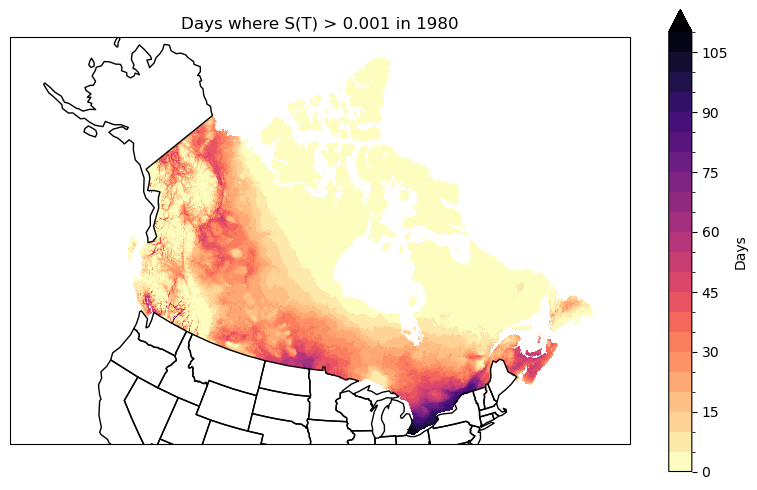

In [25]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_1980_suit["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.001 in 1980")

#plt.savefig("figures/S_0.001_1980.png", dpi=300, bbox_inches="tight")

plt.show()

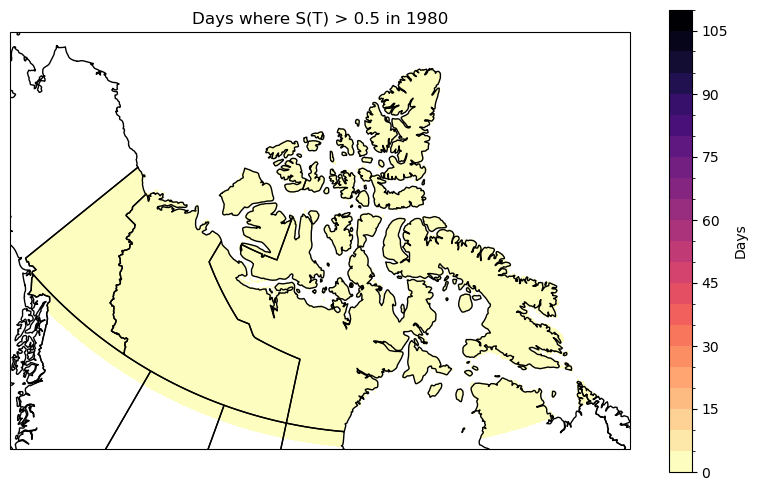

In [11]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_1980_suit_high["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.5 in 1980")

plt.savefig("figures/S_0.5_1980.png", dpi=300, bbox_inches="tight")

plt.show()

##### Historical 2: 1995-2025

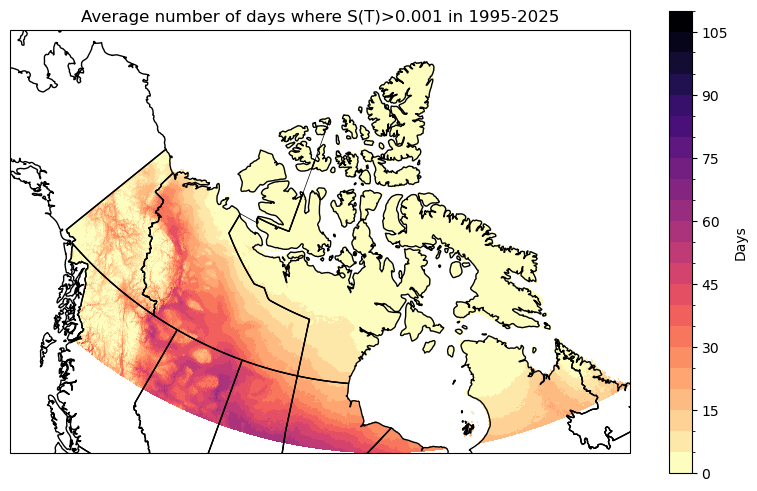

In [20]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp245_hist2_low["mean"].mean('time').plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
#ax.add_feature(cfeature.LAKES, zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.001 in 1995-2025")

plt.savefig("figures/S_0.001_1995-2025.png", dpi=300, bbox_inches="tight")

plt.show()

NameError: name 'ssp245_hist2_high' is not defined

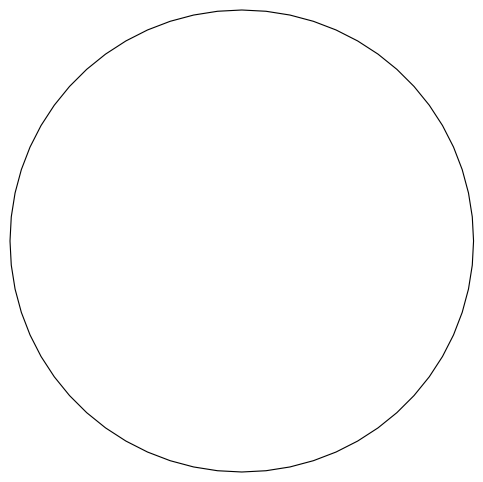

In [23]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_hist2_high["mean"].mean('time').plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Average number of days where S(T)>0.5 in 1995-2025")

plt.savefig("figures/S_0.5_1995-2025.png", dpi=300, bbox_inches="tight")

plt.show()

#### 2060

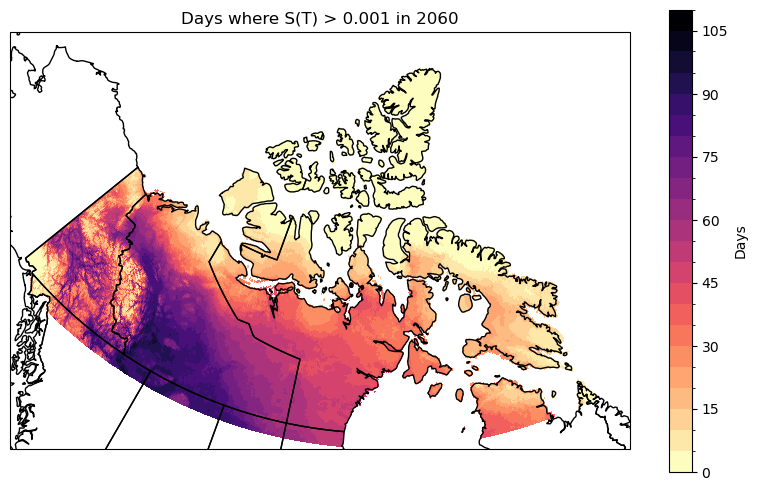

In [24]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_2060_suit["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.001 in 2060")

plt.savefig("figures/S_0.001_2060.png", dpi=300, bbox_inches="tight")

plt.show()

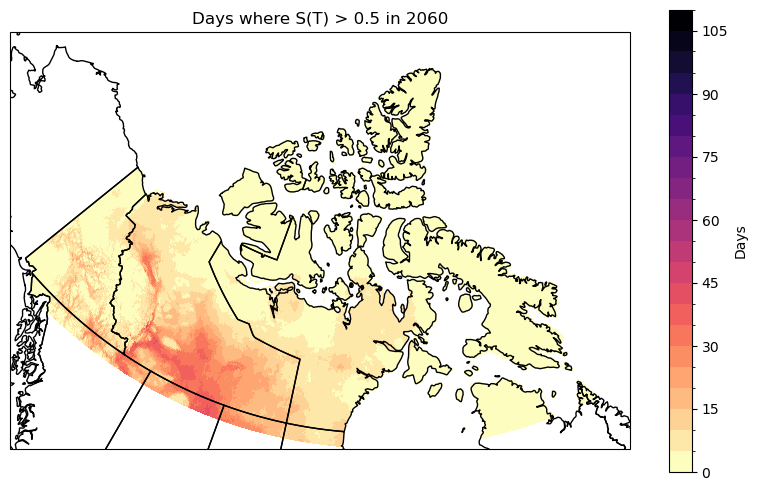

In [13]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_2060_suit_high["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.5 in 2060")

plt.savefig("figures/S_0.5_2060.png", dpi=300, bbox_inches="tight")

plt.show()

#### 2100

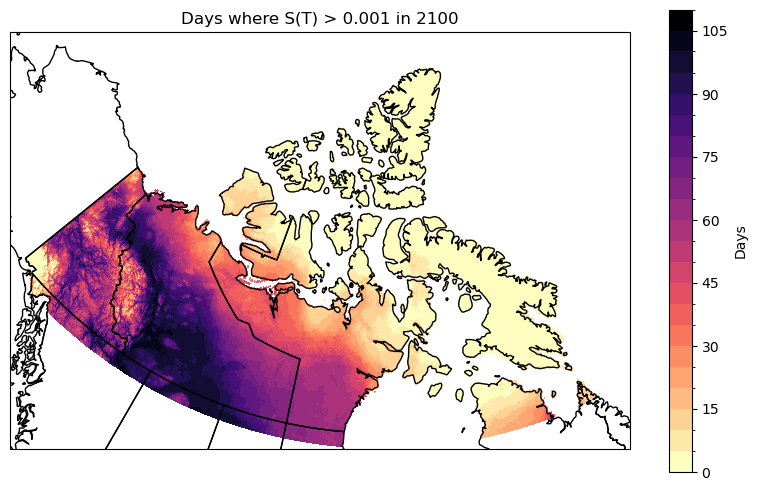

In [23]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_2100_suit["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.001 in 2100")

plt.savefig("figures/S_0.001_2100.png", dpi=300, bbox_inches="tight")

plt.show()

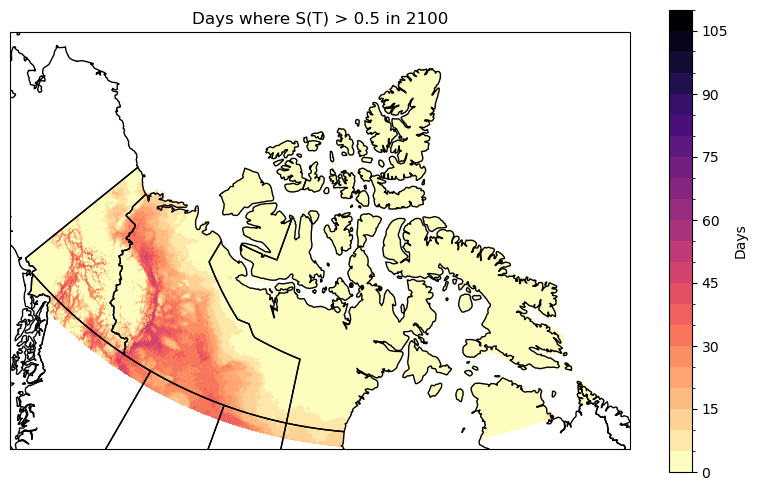

In [14]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_2100_suit_high["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.5 in 2100")

plt.savefig("figures/S_0.5_2100.png", dpi=300, bbox_inches="tight")

plt.show()

## Temperature of a random day

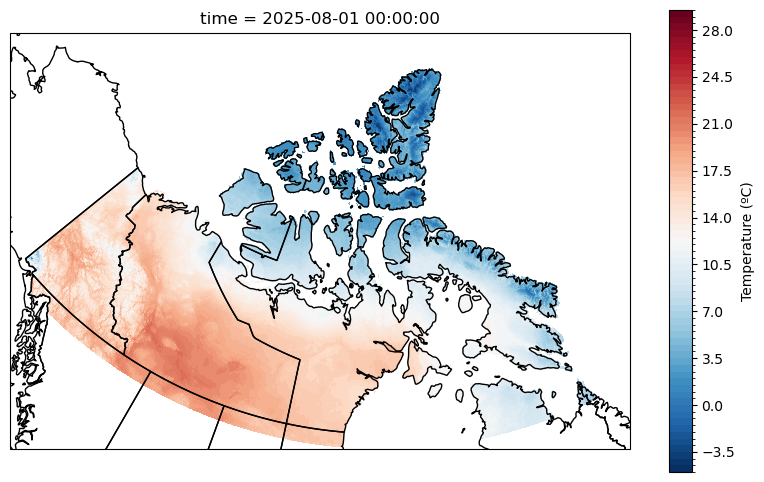

In [14]:
levels = np.arange(-5, 30, 0.5)

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
# ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# select the temperature data for a particular day
sample_time = '2025-08-01'
temp_sample = ssp245_2025.tas.sel(time = sample_time) 



# plot the data
temp_sample[0].plot.pcolormesh(ax = ax, 
                                    transform = ccrs.PlateCarree(),
                                    levels = levels, 
                                    cmap = 'RdBu_r',
                                    cbar_kwargs = {'label': 'Temperature (ºC)', 
                                                 'orientation': 'vertical'}
                                   )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot the location of Cambridge Bay and Kugluktuk as a dot
# lat_cbay = 69.1169
# lon_cbay = -105.0597
# ax.plot(lon_cbay, lat_cbay, marker = 'o', color = 'r', label = 'Cambridge Bay',
#         transform = ccrs.PlateCarree())

# lat_kug = 67.8252
# lon_kug = -115.0966
# ax.plot(lon_kug, lat_kug, marker = 'o', color = 'b', label = 'Kugluktuk',
#         transform=ccrs.PlateCarree())
# ax.legend()

# plot title
#ax.set_title("Days where S(T) > 0.001 in 2100")

plt.savefig("figures/temp.20250801.png", dpi=300, bbox_inches="tight")
plt.show()

# SSP1-2.6

In [3]:
ssp126_url = datasets_canesm_sds[1] #SSP1-2.6; ensemble member: r1i1p2f1
print(ssp126_url)
ssp126_all = xr.open_dataset(ssp126_url)[['tasmax','tasmin']]

https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r1i1p2f1_gn_1950-2100.ncml


In [5]:
ssp126 = ssp126_all

In [6]:
start_year = 1950
end_year = 1980

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp126.sel(time = ssp126.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1950...
Finished processing year 1950. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1950.nc
Processing year 1951...
Finished processing year 1951. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1951.nc
Processing year 1952...
Finished processing year 1952. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1952.nc
Processing year 1953...
Finished processing year 1953. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1953.nc
Processing year 1954...
Finished processing year 1954. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1954.nc
Processing year 1955...
Finished processing year 1955. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1955.nc
Processing year 1956...
Finished processing year 1956. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1956.nc
Proces

In [10]:
start_year = 1995
end_year = 2025

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp126.sel(time = ssp126.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1995...
Finished processing year 1995. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1995.nc
Processing year 1996...
Finished processing year 1996. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1996.nc
Processing year 1997...
Finished processing year 1997. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1997.nc
Processing year 1998...
Finished processing year 1998. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1998.nc
Processing year 1999...
Finished processing year 1999. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1999.nc
Processing year 2000...
Finished processing year 2000. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2000.nc
Processing year 2001...
Finished processing year 2001. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2001.nc
Proces

In [11]:
start_year = 2030
end_year = 2060

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp126.sel(time = ssp126.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 2030...
Finished processing year 2030. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2030.nc
Processing year 2031...
Finished processing year 2031. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2031.nc
Processing year 2032...
Finished processing year 2032. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2032.nc
Processing year 2033...
Finished processing year 2033. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2033.nc
Processing year 2034...
Finished processing year 2034. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2034.nc
Processing year 2035...
Finished processing year 2035. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2035.nc
Processing year 2036...
Finished processing year 2036. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2036.nc
Proces

In [15]:
start_year = 2070
end_year = 2100

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp126.sel(time = ssp126.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 2070...
Finished processing year 2070. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2070.nc
Processing year 2071...
Finished processing year 2071. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2071.nc
Processing year 2072...
Finished processing year 2072. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2072.nc
Processing year 2073...
Finished processing year 2073. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2073.nc
Processing year 2074...
Finished processing year 2074. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2074.nc
Processing year 2075...
Finished processing year 2075. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2075.nc
Processing year 2076...
Finished processing year 2076. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2076.nc
Proces

# SSP5-8.5

In [13]:
ssp585_url = datasets_canesm_sds[21] #SSP5-8.5; ensemble member: r1i1p2f1
print(ssp585_url)
ssp585_all = xr.open_dataset(ssp585_url)[['tasmax','tasmin']]

https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp585_r1i1p2f1_gn_1950-2100.ncml


In [17]:
ssp585 = ssp585_all

In [18]:
start_year = 1950
end_year = 1980

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1950...


KeyboardInterrupt: 

In [ ]:
start_year = 1995
end_year = 2025

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2030
end_year = 2060

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2700
end_year = 2100

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")